In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sm import NeuralNet
from tune_sm import find_control_voltages_1D
import optuna

device = 'cuda'
print(device)

def target_function(t: torch.Tensor):
    
    N = t.shape[0]
    m = nn.ReLU()
    
    return t#m(t)#0.1*t**2 + torch.sin(3*t)

def normalize_over_range(x):
    z = (x - x.mean()) / (x.std() + 1e-8) 
    return z

def forward_whole_range(model, param_list, input_idx, v_min, v_max, N):

    in_range = torch.linspace(v_min, v_max, N).unsqueeze(1)

    c_volt = torch.tensor(param_list, dtype=torch.float32).expand(N, -1)
    c_volt_l = c_volt[:, :input_idx]
    c_volt_r = c_volt[:, input_idx:]

    input_tensor = torch.cat([c_volt_l, in_range, c_volt_r], dim=1)

    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().numpy()

    return y_out

state_dict = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_vMB_n_a=200.pth", map_location="cpu", weights_only=False)
print(state_dict['args'])

x_mean = state_dict['args']['x_mean']
x_std = state_dict['args']['x_std']
y_mean = state_dict['args']['y_mean']
y_std = state_dict['args']['y_std']
layer_dims = state_dict['args']['layer_dims']

model = NeuralNet(layer_dims, x_mean, x_std, y_mean, y_std)

model.load_state_dict(state_dict['model_state_dict'])
model.eval()

N = 100
in_range = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
target = target_function(in_range)

4.4.0
cuda
cuda
{'data_dir': PosixPath('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_vMB_own_pde_solver'), 'num_batches': 180, 'batch_size': 512, 'x_mean': array([-8.01042443e-05, -4.84397956e-05,  1.27591542e-04, -1.36573186e-03,
        1.29713429e-03,  9.82766649e-04, -6.81038087e-04]), 'x_std': array([0.86585553, 0.86589274, 0.86606062, 0.865617  , 0.86568139,
       0.86553458, 0.86612566]), 'y_mean': np.float64(-0.03779365664983197), 'y_std': np.float64(0.14455336756115278), 'layer_dims': [7, 128, 128, 128, 1], 'num_epochs': 500, 'lr': 0.001, 'save_name': PosixPath('/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_vMB_n_a=200')}


In [6]:
study = find_control_voltages_1D(
    model=model, 
    target=target, 
    N=N, 
    c_volt_min=-1.5, 
    c_volt_max=1.5, 
    in_volt_min=-1.5, 
    in_volt_max=1.5, 
    input_idx=0, 
    n_startup_trials=500, 
    n_trials=1000, 
    PRINT_EVERY=100
)

print("Best value:", study.best_value)
print("Best params:", study.best_params)  

best_vals = []

for v in study.best_params.items():
    best_vals.append(v[1])
print(best_vals)

0] Finished with score:  0.135173
100] Finished with score:  0.265448
200] Finished with score:  0.161367
300] Finished with score:  0.144044
400] Finished with score:  0.280752
500] Finished with score:  0.105756
600] Finished with score:  0.032827
700] Finished with score:  0.038208
800] Finished with score:  0.034280
900] Finished with score:  0.033142
Best value: 0.03164363044500351
Best params: {'x_0': -1.4993585571687573, 'x_1': -1.4940815046433964, 'x_2': -0.8351970808666014, 'x_3': 0.9108973804341518, 'x_4': 1.2629079376914545, 'x_5': 1.4985793189762304}
[-1.4993585571687573, -1.4940815046433964, -0.8351970808666014, 0.9108973804341518, 1.2629079376914545, 1.4985793189762304]


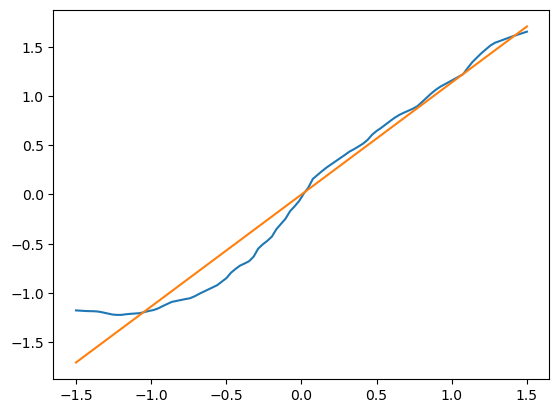

In [7]:
y_out = forward_whole_range(model, best_vals, 0, -1.5, 1.5, N) 

y_norm = normalize_over_range(y_out)
t_norm = normalize_over_range(target)

plt.plot(in_range, y_norm)
plt.plot(in_range, t_norm)

In [3]:
num_runs = 200
opt_param_list = []
for i in range(num_runs):
    study = find_control_voltages_1D(
        model=model, 
        target=target, 
        N=N, 
        c_volt_min=-1.5, 
        c_volt_max=1.5, 
        in_volt_min=-1.5, 
        in_volt_max=1.5, 
        input_idx=0, 
        n_startup_trials=100, 
        n_trials=1000, 
        PRINT_EVERY=100000
    )
    if i % 10 == 0:
        print("Best value:", study.best_value)
        print("Best params:", study.best_params)  
    
    best_vals = []
    
    for v in study.best_params.items():
        best_vals.append(v[1])
    opt_param_list.append(best_vals)

0] Finished with score:  0.380789
Best value: 0.018745626360177993
Best params: {'x_0': -0.4678383546181246, 'x_1': -0.9406975757714735, 'x_2': -1.4944357616852653, 'x_3': -1.4990110670469776, 'x_4': -1.3937316450259496, 'x_5': -0.7557526841126032}
0
0] Finished with score:  0.376528
1
0] Finished with score:  0.207961
2
0] Finished with score:  0.901804
3
0] Finished with score:  0.421638
4
0] Finished with score:  1.015560
5
0] Finished with score:  0.280775
6
0] Finished with score:  0.105068
7
0] Finished with score:  1.273438
8
0] Finished with score:  0.383498
9
0] Finished with score:  0.231158
Best value: 0.009309311382472514
Best params: {'x_0': -1.4974779342987359, 'x_1': -1.4433435593086807, 'x_2': -1.452484290330141, 'x_3': -0.6900039222066094, 'x_4': 1.1935158178548062, 'x_5': -0.6690948465287797}
10
0] Finished with score:  0.353437
11
0] Finished with score:  0.407407
12
0] Finished with score:  0.109300
13
0] Finished with score:  0.188820
14
0] Finished with score:  0.

[W 2025-10-13 10:17:54,594] Trial 485 failed with parameters: {'x_0': -1.4995865634829268, 'x_1': -1.2811179833664113, 'x_2': -1.1354231862764819, 'x_3': 0.25652157782221013} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/hd/hd_hd/hd_gy283/kmc_project/scripts/python_scripts/tune_sm.py", line 34, in objective
    cv_list = [trial.suggest_float(f"x_{i}", c_volt_min, c_volt_max) for i in range(6)]
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hd/hd_hd/hd_gy283/kmc_project/scripts/python_scripts/tune_sm.py", line 34, in <listcomp>
    cv_list = [trial.suggest_float(f"x_{i}", c_volt_min, c_volt_max) for i in range(6)]
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


KeyboardInterrupt: 

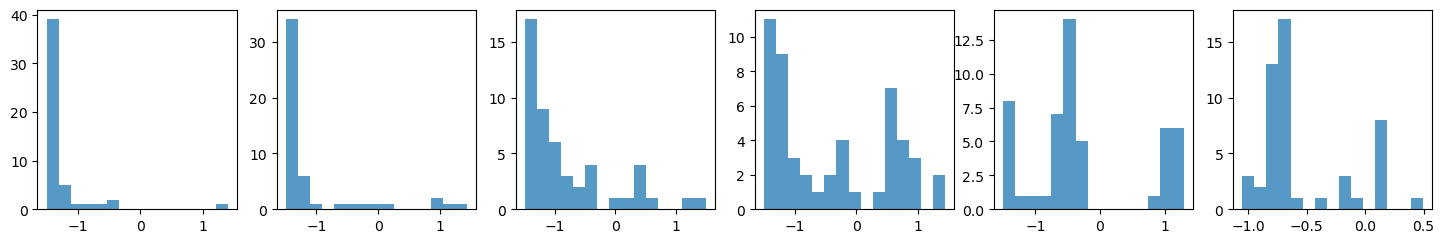

In [8]:
opt_param_arr = np.stack(opt_param_list)
np.save('opt_param_arr_relu_opt.npy', opt_param_arr)
d = 6
fig, ax = plt.subplots(ncols=d, figsize=(3*d, 3))

for a in ax:
    a.set_box_aspect(1)

for i in range(d):
    ax[i].hist(opt_param_arr[:, i], bins=15, alpha=.75)

## 2.)  2D

In [4]:
xs, ys = np.meshgrid(np.linspace(-1.5, 1.5, N), np.linspace(-1.5, 1.5, N))

def target_2d(x, y):
    z = 1 / (1 + x - y)
    